# Capstone: Define and Solve an ML Problem

In [1]:
import pandas as pd
import numpy as np
import os 
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder 
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
import tensorflow.keras as keras
from sklearn.preprocessing import StandardScaler
import time

## Part 1: Build The DataFrame

**Census Income Data** (`censusData.csv`):
This data set contains demographic and employment information from the 1994 U.S. Census. I will use it to predict whether an individual's annual income exceeds $50,000. My label column is `income_binary`, which contains two values: `<=50K` and `>50K`. I will need to convert this column into a binary numeric label (for example, 0 and 1) during data preparation.


In [ ]:
census_filename = os.path.join(os.getcwd(), "data", "censusData.csv")

df = pd.read_csv(census_filename)

df.head(10)

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex_selfID,capital-gain,capital-loss,hours-per-week,native-country,income_binary
0,39.0,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Non-Female,2174,0,40.0,United-States,<=50K
1,50.0,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Non-Female,0,0,13.0,United-States,<=50K
2,38.0,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Non-Female,0,0,40.0,United-States,<=50K
3,53.0,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Non-Female,0,0,40.0,United-States,<=50K
4,28.0,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40.0,Cuba,<=50K
5,37.0,Private,284582,Masters,14,Married-civ-spouse,Exec-managerial,Wife,White,Female,0,0,40.0,United-States,<=50K
6,49.0,Private,160187,9th,5,Married-spouse-absent,Other-service,Not-in-family,Black,Female,0,0,16.0,Jamaica,<=50K
7,52.0,Self-emp-not-inc,209642,HS-grad,9,Married-civ-spouse,Exec-managerial,Husband,White,Non-Female,0,0,45.0,United-States,>50K
8,31.0,Private,45781,Masters,14,Never-married,Prof-specialty,Not-in-family,White,Female,14084,0,50.0,United-States,>50K
9,42.0,Private,159449,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Non-Female,5178,0,40.0,United-States,>50K


## Part 2: Define The Problem

For this problem, my label will be the income_binary column to predict if individuals have an income of above or below $50k. After peeking at the DataFrame, I plan to use education, hours-per-week, occupation, and age as features in an attempt to reduce introducing bias into my model.

## Part 3: Understanding the Data

Now that the problem has been defined, exploratory data analysis (EDA) will be performed with the following considerations in mind:

1. Data preparation techniques:
    * handling missing values
    * finding and replacing outliers
    * performing feature engineering techniques such as one-hot encoding on categorical features
    * selecting appropriate features and removing irrelevant features
    * addressing class imbalance

2. Which machine learning model is most suitable for this predictive problem given the data?
    * K-Nearest Neighbors (KNN)
    * Decision Tree
    * Logistic Regression

### Class Imbalance

Examining the distribution of the label column will determine whether class imbalance is present.

<=50K    24720
>50K      7841
Name: income_binary, dtype: int64
<=50K    75.919044
>50K     24.080956
Name: income_binary, dtype: float64


Text(0, 0.5, 'Count')

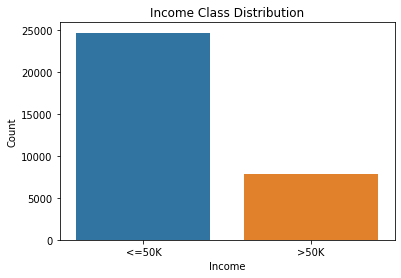

In [ ]:
print(df['income_binary'].value_counts())
print(df['income_binary'].value_counts(normalize=True) * 100)

sns.countplot(x='income_binary', data=df)
plt.title('Income Class Distribution')
plt.xlabel('Income')
plt.ylabel('Count')

### Inspect and Analyzing the Data

Analyzing the data will reveal issues such as missing values, outliers, or redundant/irrelevant features.

Basic Structure: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             32399 non-null  float64
 1   workclass       30725 non-null  object 
 2   fnlwgt          32561 non-null  int64  
 3   education       32561 non-null  object 
 4   education-num   32561 non-null  int64  
 5   marital-status  32561 non-null  object 
 6   occupation      30718 non-null  object 
 7   relationship    32561 non-null  object 
 8   race            32561 non-null  object 
 9   sex_selfID      32561 non-null  object 
 10  capital-gain    32561 non-null  int64  
 11  capital-loss    32561 non-null  int64  
 12  hours-per-week  32236 non-null  float64
 13  native-country  31978 non-null  object 
 14  income_binary   32561 non-null  object 
dtypes: float64(2), int64(4), object(9)
memory usage: 3.7+ MB
None
(32561, 15)

Summary Stats:
             

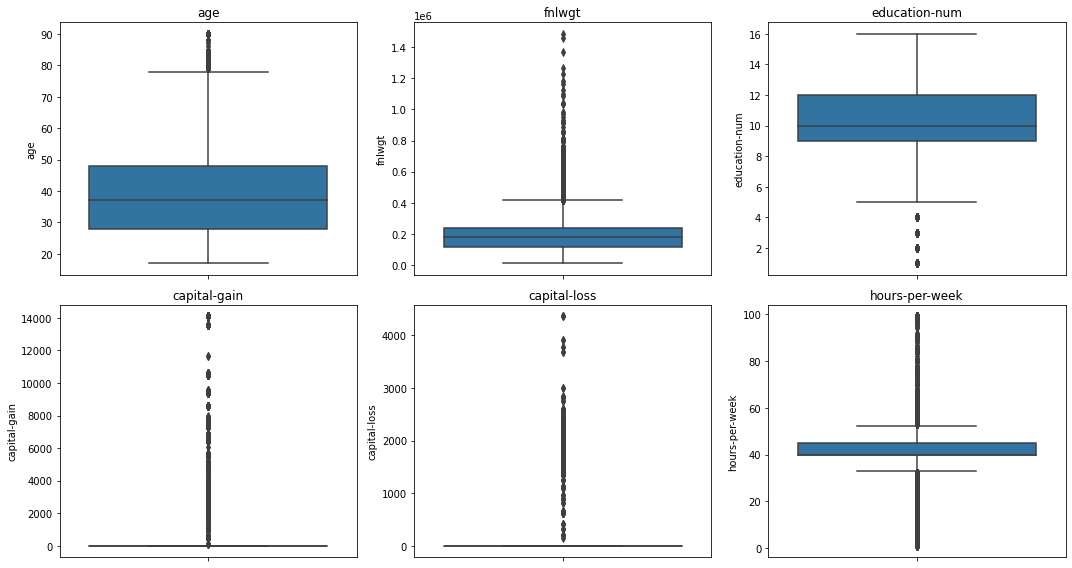


Categorical Feature Distribution: 
Private             22696
Self-emp-not-inc     2541
Local-gov            2093
State-gov            1298
Self-emp-inc         1116
Federal-gov           960
Without-pay            14
Never-worked            7
Name: workclass, dtype: int64

HS-grad         10501
Some-college     7291
Bachelors        5355
Masters          1723
Assoc-voc        1382
11th             1175
Assoc-acdm       1067
10th              933
7th-8th           646
Prof-school       576
9th               514
12th              433
Doctorate         413
5th-6th           333
1st-4th           168
Preschool          51
Name: education, dtype: int64

Married-civ-spouse       14976
Never-married            10683
Divorced                  4443
Separated                 1025
Widowed                    993
Married-spouse-absent      418
Married-AF-spouse           23
Name: marital-status, dtype: int64

Prof-specialty       4140
Craft-repair         4099
Exec-managerial      4066
Adm-clerica

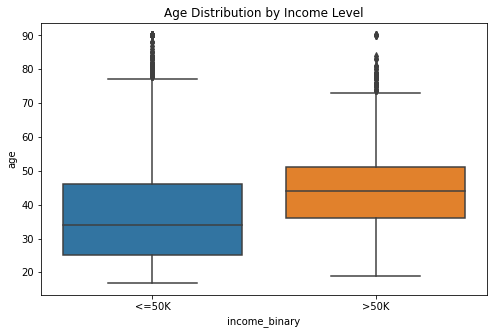

<Figure size 720x360 with 0 Axes>

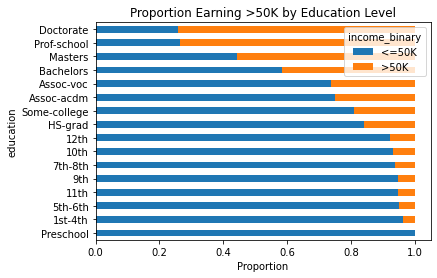

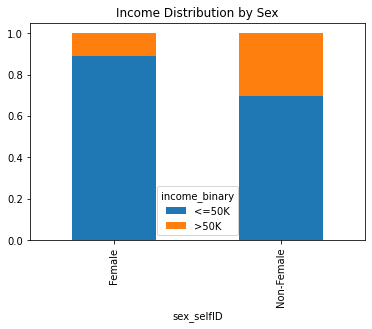

In [ ]:
print("Basic Structure: ")
print(df.info())
print(df.shape)
print()

print("Summary Stats:")
print(df.describe())
print("Check education and education-num uniqueness: \n", df.groupby('education')['education-num'].unique())
print()

print("Missing Values: ")
print(df.isnull().sum())
print("Workclass and occupation missing shape: \n", df[df['workclass'].isnull() & df['occupation'].isnull()].shape[0])
print()
    
print("Outlier Detection: ")
numeric_cols = df.select_dtypes(include=["number"]).columns.tolist()
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flatten(), numeric_cols):
    sns.boxplot(y=df[col], ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()
print()

print("Categorical Feature Distribution: ")
cat_cols = df.select_dtypes(include=["category", "object"]).columns.tolist()

for col in cat_cols:
    print(df[col].value_counts())
    print()
print()

print("Feature vs Label Plot")
plt.figure(figsize=(8, 5))
sns.boxplot(x='income_binary', y='age', data=df)
plt.title('Age Distribution by Income Level')
plt.show()

plt.figure(figsize=(10, 5))
pd.crosstab(df['education'], df['income_binary'], normalize='index').sort_values('>50K').plot(kind='barh', stacked=True)
plt.title('Proportion Earning >50K by Education Level')
plt.xlabel('Proportion')
plt.show()

pd.crosstab(df['sex_selfID'], df['income_binary'], normalize='index').plot(kind='bar', stacked=True)
plt.title('Income Distribution by Sex')
plt.show()

### EDA Summary

Below, I have included a summary of what I've found after exploratory data analysis:

Class Imbalance: 
- The label income_binary appears to be rather imbalanced, with 75% of records being <= 50k and the other 25% at > 50k. This implies that accuracy alone would be a misleading metric later on, since a model that always predicts <= 50k would be around 75% accurate. To address this problem, I'll evaluate with precision, recall, F1, and confusion matrix instead of just accuracy alone.

Missing values: 
- There appears to be 3 columns with a significant amount of missing data, from workclass (1836), occupation (1843), and native-country (583). After seeing how close in value the missing value numbers were from workclass and occupation, I checked for the overlap between the two features and found that they almost entirely overlap. All 1836 of the missing occupation rows were also missing in workclass, which intuitively means that someone with no occupation also has no work status to report. Thus, I plan on filling both with an explicit unknown category rather than fill in values from other data in the dataset. For the features with less missing values, I will use median imputation for native-country, age, and hours-per-week since the missing data is also less patterned.

Redundant features: 
- It appears that education and education-num are a clean 1 to 1 encoding of the same information, so I plan on dropping the string education column and keeping the numeric version. fnlwgt appears to be a Census sampling weight rather than a meaningful attribute to individuals, so it doesn't contribute anything to a person's employment/background. Thus, I plan on dropping that feature as well.

Outliers:
- Boxplots show that there are heavy outliers in capital-gain/loss and fnlwgt. Since fnlwgt will be dropped, this information is not too relevant. For capital-gain/loss, I plan to treat the skew with a log transform to avoid distorting distance based models like KNN

Feature Label Relationships:
- Age and education show a clear relationship with income, with median age generally higher for > 50k group and a lower median age for the group earning <= 50k.

Sensitive Features/Fairness:
- Sex, race, and native-country do show disparities in income outcomes that are worth noting before modeling. Notably, only ~11% of individuals labeled female earn > 50k compared to the ~30% of individuals identifying as non-Female. This kind of gap that a model learns can have an overall negative effect. Since, other features like relationship or occupation can somewhat act as proxies, I plan to exclude these sensitive feaatures from features used to train the models and evaluate the model's error rates across these features after training.

### Ethical Considerations:

Since machine learning models can cause harm when they reflect or amplify biases in the data they are trained on, here are some considerations to keep in mind.

Since the dataset is from the 1994 Census, this may reflect the economic and social structure of the U.S. labor market and society from decades ago. This can lead to historical biases including wage gaps, occupational segregation, and various demographic patterns from this time. Moreover, representation is uneven across groups. Most of the data is from white United States citizens, with several races/native country individuals represented far less. A model trained on this data would be exposed to fewer examples of underrepresented groups, so the predictions for such groups would be less reliable and error prone. Additionally, there are several features that are proxies for protected characteristics. For one, the relationship column is highly correlated with gender (husband/wife). Moreover, the occupation column seems to have a noticeable pattern that correlate race and origin. 

With that in mind, the most direct harm from a model trained on this dataset would be false negatives. This would be where the model predicts > 50k for someone who actually would be making <= 50k, who would be strongly qualified for the CDFI's programs. This individual who gets incorrectly excluded from outreach directly contradicts the CDFI's goal of reaching underserved and low income communities. Groups already underrepresented in the training data, such as some race categories, non US born individuals, and women are more likely to be misclassified since the model has seen less reliable examples of their income patterns which may further disadvantage communities the CDFI is trying to target.

## Part 4: Preparing the Data

In [ ]:
df_model = df.drop(columns=['fnlwgt', 'education'])

# missing categorical values
df_model['workclass'] = df_model['workclass'].fillna('Unknown')
df_model['occupation'] = df_model['occupation'].fillna('Unknown')
df_model['native-country'] = df_model['native-country'].fillna('Unknown')

# missing numeric values
df_model['age'] = df_model['age'].fillna(df_model['age'].median())
df_model['hours-per-week'] = df_model['hours-per-week'].fillna(df_model['hours-per-week'].median())

sensitive_features = df[['sex_selfID', 'race', 'native-country']].copy()
df_model = df_model.drop(columns=['sex_selfID', 'race', 'native-country'])

In [6]:
X = df_model.drop(columns=['income_binary'])
y = df_model['income_binary'].map({'<=50K': 0, '>50K': 1})

categorical_cols = X.select_dtypes(include='object').columns.tolist()
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

sensitive_test = sensitive_features.loc[X_test.index]

### Data Preparation Summary:

After EDA, here is a summary of steps I took to prep the data:
1. Drop fnlwgt. Fnlwgt is not a real attribute for individuals, but instead is a weight used for population estimation. There is no relationship between fnlwgt and income potential.
2. Drop education. During EDA, I confirmed that education and education-num are a 1-to-1 encoding of education level. Keeping both features would be redundant so I kept the numeric column and dropped the categorical version.
3. Handled missing values in categorical columns. I filled missing values in workclass, occupation, and native-country with "Unknown" category. During EDA, I found that the missing workclass and occupation values highly overlapped and therefore should not be imputed since the missingness is structured and not an error. Despite smaller amount of missing values in native-country, I applied the same approach since there is no way to guess or impute someone's native country without distorting or fabricating information.
4. Handled missing values in numemrical columns. In age and hour-per-week, I filled missing values with median imputation. The amount of missing values in these columns were low, with no structured pattern that the workclass and occupation showed. Thus, a median imputation was reasonable.
5. Removed sensitive characteristics from training features, but stored for later. With ethical and fairness concerns towards the race, gender, and native-country columns, I decided to remove but store the features to test on after training. This way, I can evaluate the model's error rates across these groups after training and check for disparities in model predictions. However, other features that may serve as a proxy for these characteristics may not fully guarantee unbiased results.
6. Mapped income_binary to numeric binary values. This was done so that the label was usable with sklearn evaluation tools. Additionally, this ensures that I know which outcome is treated as a positive.
7. One hot encoding on remaining categorical features. I used drop_first=True with get_dummy() to avoid redundant dummy columns. One hot encoding was needed since neither KNN, Decision Tree, nor logistic regression models can use raw string features directly.
8. Chose not to apply feature scaling. Since I am choosing to use a decision tree model for more transparecy in decision making, scaling isn't necessary since trees split on values within a single feature at a time rather than relying on distance across features.
9. Used an 80/20 stratified train test split. I used stratify=y in train_test_split() to ensure both training and test sets that the model is evaluated on has an equal proportion of examples. To account for the class imbalance within the dataset, I plan on using class_weight='balanced" when instantiating the DecisionTreeClassifer() model to avoid leaning towards more popular data values.

## Part 5: Train, Test, Evaluate, and Improve a Traditional Machine Learning Model

In [ ]:
# Create labeled examples from the dataset
print("Labeled examples (X, y):", X.shape, y.shape)

Labeled examples (X, y): (32561, 38) (32561,)


In [ ]:
# Create training and test sets out of the labeled examples 
print("Training set:", X_train.shape, y_train.shape)
print("Test set:", X_test.shape, y_test.shape)

Training set: (26048, 38) (26048,)
Test set: (6513, 38) (6513,)


In [ ]:
# Train, test and evaluate the model
model = DecisionTreeClassifier(class_weight='balanced', random_state=42)
model.fit(X_train, y_train)

predictions = model.predict(X_test)

acc = accuracy_score(y_test, predictions)
f1 = f1_score(y_test, predictions, average='binary')

print('Initial Model:')
print('Accuracy: ', acc)
print('F1: ', f1)
print('\nConfusion Matrix:\n', confusion_matrix(y_test, predictions))
print('\nClassification Report:\n', classification_report(y_test, predictions))

Initial Model:
Accuracy:  0.8125287885766928
F1:  0.6312292358803986

Confusion Matrix:
 [[4247  698]
 [ 523 1045]]

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.86      0.87      4945
           1       0.60      0.67      0.63      1568

    accuracy                           0.81      6513
   macro avg       0.74      0.76      0.75      6513
weighted avg       0.82      0.81      0.82      6513



In [ ]:
# Perform model selection through grid search cross-validation (GridSearchCV)
param_grid = {
    'max_depth': [3, 5, 7, 10, 15],
    'min_samples_leaf': [1, 5, 10, 20],
    'min_samples_split': [2, 10, 20],
    'criterion': ['gini', 'entropy']
}

dt_grid = DecisionTreeClassifier(class_weight='balanced', random_state=42)

grid_search = GridSearchCV(estimator=dt_grid, param_grid=param_grid, scoring='f1', cv=5, n_jobs=-1)

grid_search.fit(X_train, y_train)

print("Best hyperparams: ", grid_search.best_params_)
print("Best cross-validated f1: ", grid_search.best_score_)

Best hyperparams:  {'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 5, 'min_samples_split': 2}
Best cross-validated f1:  0.6787067460027346


In [ ]:
# Train, test and evaluate a final version of the model using the optimal hyperparameter values.
final_model = DecisionTreeClassifier(max_depth=10, min_samples_leaf=5, min_samples_split=2, criterion='entropy', class_weight='balanced', random_state=42)
final_model.fit(X_train, y_train)
final_predictions = final_model.predict(X_test)

acc_final = accuracy_score(y_test, final_predictions)
f1_final = f1_score(y_test, final_predictions, average='binary')

print("Final Tuned Model:")
print("Accuracy: ", acc_final)
print("F1 (class 1, >50K): ", f1_final)
print("\nConfusion Matrix:\n", confusion_matrix(y_test, final_predictions))
print("\nClassification Report:\n", classification_report(y_test, final_predictions))

final_results = {
    'model': 'Decision Tree (tuned)',
    'accuracy': acc_final,
    'f1_score': f1_final
}
print(final_results)

Final Tuned Model:
Accuracy:  0.803930600337786
F1 (class 1, >50K):  0.6795483061480552

Confusion Matrix:
 [[3882 1063]
 [ 214 1354]]

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.79      0.86      4945
           1       0.56      0.86      0.68      1568

    accuracy                           0.80      6513
   macro avg       0.75      0.82      0.77      6513
weighted avg       0.85      0.80      0.82      6513

{'model': 'Decision Tree (tuned)', 'accuracy': 0.803930600337786, 'f1_score': 0.6795483061480552}


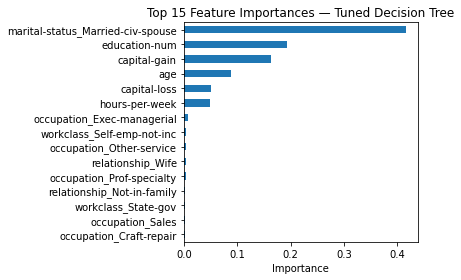

marital-status_Married-civ-spouse    0.416846
education-num                        0.193561
capital-gain                         0.162314
age                                  0.088176
capital-loss                         0.049983
hours-per-week                       0.048313
occupation_Exec-managerial           0.008247
workclass_Self-emp-not-inc           0.004339
occupation_Other-service             0.004336
relationship_Wife                    0.003855
occupation_Prof-specialty            0.003184
relationship_Not-in-family           0.002053
workclass_State-gov                  0.001565
occupation_Sales                     0.001426
occupation_Craft-repair              0.001371
dtype: float64


In [ ]:
# Interpreting model outputs 

importances = pd.Series(final_model.feature_importances_, index=X_train.columns)
top_importances = importances.sort_values(ascending=False).head(15)

plt.figure()
top_importances.sort_values().plot(kind='barh')
plt.title('Top 15 Feature Importances — Tuned Decision Tree')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

print(top_importances)

### Model Reflection:

In terms of the model, I chose the Decision tree model. I chose this model for a few reason. For one, the dataset is a mix of numeric and categorical values. Decision trees handle such data without requiring feature scaling, which is an advantage over disatance based models where one hot encoding several cat columns could distort distance calculations. In a more intuitive sense, interpretability is clearer with decision trees. Decision trees make it easier to point to specific decision rules to explain the model's behavior to a non-technical client. Additionally, the dataset's class imbalance is addressable with class_weight='balanced' without needing to alter or give weight to the given data.

My biggest takeaway during this process was that grid search optimizing for a metric doesn't automatically align with the business goal. When I ran GridSearchCV on f1 scores, it improved f1 score tuning for class 1. Since I encoded >50k as 1 and <=50k as 0, this improved the model's ability to predict >50k at the expense of recall on <=50k predictions. This actually contradicted the business goal, which is to target lower income groups. Thus, I realized that the choice of which class to treat as positive and which metric to optimize during tuning needs to reflect real-world objectives and business goals. I also learned how easily small implementation mistakes can produce misleading results. At one point, I forgot to reassign my df_model after dropping various columns which affected the outcomes of my model. This tiny mistake led to multiple reread throughs and reruns of the entire pipeline.

The tuned decision tree's feature importances show that three features drive the majority of decisions, which are marital-status_Married-civ-spouse, education-num, and capital-gain. Other features like age, capital-loss, and hours-per-week contribute modestly, while occupation, workclass, and relationship contribute the least. I interpret this as the model learning that married, civilian spouse households, higher education, and capital gains incomes are the strongest signal of earning >50k. It also means that the model is relying less on job specific features like occupation/workclass than I expected at first.

There are still several concerns regarding fairness. For one, proxy features still appear to have significant impact. Even after excluding sensitve features, the dominant feature, marital-status_Married-civ-spouse is a plausable proxy for gender roles during this time of Census data. Excluding explicit demographic columns didn't fully prevent the model from learnign patterns correlated with gender, which is a notable concern. Moreover, the label itself reflects historical inequality with a 19% gap in >50k rates between Female and non-Female individuals. A model learns to predict from this data rather than correct it, regardless of features excluded. In terms of race, several race and native-country categories had very sparse records, meaning fewer examples and thus less reliable predictions for these groups. Currently at the most risk are individuals that are actually earning <=50k but incorrectly labeled as >50k. After evaluating, data shows that this error becomes more frequent after hyperparam tuning (recall for <=50k class dropped from 0.86 to 0.79). Even more specifically, individuals from underrepresented race/native-country groups and women are more likely to be misclassified.

---
## Preparing to Train and Compare with a Neural Network Model


### Preparing Data for the Neural Network

Before training the network, I'll create scaled versions of the training and test data using `StandardScaler()` from `sklearn.preprocessing` to standardize the features. 

In [ ]:
scaler = StandardScaler()

# Fit the scaler on the training data and transform the training data
X_train_scaled = scaler.fit_transform(X_train)

# Use the same scaler to transform the test data
X_test_scaled = scaler.transform(X_test)

### Step 1: Define the Model Architecture

I will use the Keras `Sequential` class to build the network. 

In [ ]:
n_features = X_train_scaled.shape[1]

nn_model = keras.Sequential()

nn_model.add(keras.layers.Input(shape=(n_features,)))

# I chose two hidden layers with 64 and 32 units using ReLU as a reasonable starting
# depth, which is deep enough to capture non-linear interactions between features without
# being too deep to the point that it overfits.

nn_model.add(keras.layers.Dense(64, activation='relu'))
nn_model.add(keras.layers.Dense(32, activation='relu'))

nn_model.add(keras.layers.Dense(1, activation='sigmoid'))

nn_model.summary()

Model: "sequential_4"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense_5 (Dense)              (None, 64)                2496      
_________________________________________________________________
dense_6 (Dense)              (None, 32)                2080      
_________________________________________________________________
dense_7 (Dense)              (None, 1)                 33        
Total params: 4,609
Trainable params: 4,609
Non-trainable params: 0
_________________________________________________________________


### Step 2:  Define the Optimization Function

In [ ]:
# I'll use a learning rate of 0.01 as a starting point, it's small enough to avoid overshooitng losses, but large enough
# that training doesn't take on too many epochs.
sgd_optimizer = keras.optimizers.SGD(learning_rate=0.01)

### Step 3: Define the Loss Function

I'll create a binary cross entropy loss function using `keras.losses.BinaryCrossentropy()` using  the parameter `from_logits=False`. 

In [ ]:
loss_fn = keras.losses.BinaryCrossentropy(from_logits=False)

### Step 4: Compile the Model



In [ ]:
nn_model.compile(optimizer=sgd_optimizer, loss=loss_fn, metrics=['accuracy'])

### Step 5: Fit the Model to the Training Data

In [31]:
class ProgBarLoggerNEpochs(keras.callbacks.Callback):
    
    def __init__(self, num_epochs: int, every_n: int = 50):
        self.num_epochs = num_epochs
        self.every_n = every_n
    
    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % self.every_n == 0:
            s = 'Epoch [{}/ {}]'.format(epoch + 1, self.num_epochs)
            logs_s = ['{}: {:.4f}'.format(k.capitalize(), v)
                      for k, v in logs.items()]
            s_list = [s] + logs_s
            print(', '.join(s_list))


In [ ]:
# I chose 30 epochs as a starting point since its smalle enough to show meaningful convergence,
# without being too much that it takes very long or overfits.
t0 = time.time() # start time

num_epochs = 30  

history = nn_model.fit(X_train_scaled, y_train, validation_split=0.2, epochs=num_epochs, verbose=0)# YOUR CODE HERE 

t1 = time.time() # stop time

print('Elapsed time: %.2fs' % (t1-t0))

Elapsed time: 39.13s


### Step 6: Visualize Training Performance

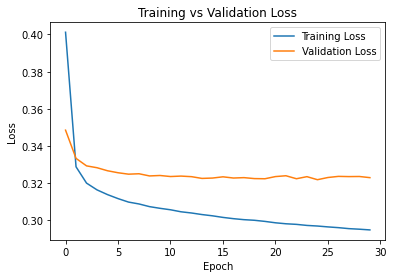

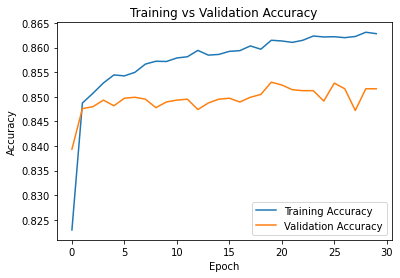

In [ ]:
# training loss and validation loss over epochs
plt.figure()
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()
# training accuracy and validation accuracy over epochs
plt.figure()
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

### Step 7: Evaluate the Model's Performance on the Test Set

In [ ]:
nn_pred = nn_model.predict(X_test_scaled)
nn_predictions = (nn_pred >= 0.5).astype(int).flatten()

In [ ]:
nn_accuracy = accuracy_score(y_test, nn_predictions)
nn_f1 = f1_score(y_test, nn_predictions, average='binary')

print("Neural Network Model:")
print("Accuracy: ", nn_accuracy)
print("F1: ", nn_f1)
print("\nConfusion Matrix:\n", confusion_matrix(y_test, nn_predictions))
print("\nClassification Report:\n", classification_report(y_test, nn_predictions))

nn_results = {
    'model': 'Neural Network',
    'accuracy': nn_accuracy,
    'f1_score': nn_f1
}
print(nn_results)

Neural Network Model:
Accuracy:  0.8576692768309535
F1:  0.68133379168099

Confusion Matrix:
 [[4595  350]
 [ 577  991]]

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.93      0.91      4945
           1       0.74      0.63      0.68      1568

    accuracy                           0.86      6513
   macro avg       0.81      0.78      0.79      6513
weighted avg       0.85      0.86      0.85      6513

{'model': 'Neural Network', 'accuracy': 0.8576692768309535, 'f1_score': 0.68133379168099}


#### Neural Network Reflection:

I built a model with two layers of 64 and 32  units with ReLU activiation for both. I chose two layers as a reasonable depth, enough for the network to learn non linear interactions without unnecessary complexity. I chose the units at 64 to 32 to progressively compress the inputs into more abstract representations. ReLU was chosen for the layers since its efficient and avoids vanishing gradient issues prevalanet with other activiations. For the output layer, I chose the sigmoid activation which is most appropriate for binary classification problems since it outputs a value between 0 and 1. This can be interpreted as the predicted probability for the > 50k class. For the learning rate, I chose 0.01 since it's high enough to make training progress within a reasonable number of epochs but low enough to avoid unstable loss. In terms of number of epochs, I chose 30 to be a starting point since its smalle enough to show meaningful convergence without being too much that it takes very long or overfits.

In terms of the curves, the training curves showed mild overfitting. Training loss had an initial rapid decrease before leveling out to around 0.28, while validation decreased steadly and plateaued around 0.32. The same pattern can be seen in accuracy, where training accuracy rises between 0.85-0.86, while validation accuracy plateaues and fluctuates around 0.84-0.85. This tells me that learning largely happens around 5-10 epochs, and after this point the network reduces training error by fiting patterns specific to the training data. Since the validation performance doesn't get worse and just stops improving, this suggests mild overfitting.

On the test set, the model achieved an accuracy of 0.858 and F1 score of 0.681. This result did not surprise me, despite mild overfitting visible in the training curves. Since the overfitting was mild, the model still generalized reasonably well to the test set.

## Part 7: Compare the Models and Reflect

In [ ]:
results = pd.DataFrame({
    'Metric': ['Accuracy', 'F1 Score'],
    'Decision Tree': [acc_final, f1_final],
    'Neural Network': [nn_accuracy, nn_f1]
})
print(results.to_string(index=False))

   Metric  Decision Tree  Neural Network
 Accuracy       0.803931        0.857669
 F1 Score       0.679548        0.681334


### Comparative Analysis

The neural network outperformed the Decision Tree on both accuracy and F1 score. Accuracy improved from 0.804 to 0.878, and F1 improved slightly from 0.68 to 0.681. Looking deeper at the classification reports, the neural network achieved 0.93 recall on the <=50k class, compared to the decision tree's 0.79. This is a substantial improvement for identifying eligible individuals, which is the most relevant to the business goal. No metric got meaningfully worse for the neural network except the neural network's precision for class 0, which was slightly lower than the decision's tree from 0.89 to 0.95 respectively. 

For this problem, I think the complexity was worth it overall. Despite a more complex setup (architectory, learning rate, num eoichs, etc), the performance gain isn't trivial. In particular, the recall improvement on the target class is quite significant in the larger scheme of business goals and needs. In addition, the added complexity was manageable since trainig took a reasonable amount of time and architecture decisions weren't too difficult to reason about or justify.

I would recommend the neural network for this specific case, primarily due to it's improved performance for the <= 50k class. Given that the most damaging error for the CDFI is failing to identify a truly qualified individiual, a model that misses fewer cases serves their mission better at the tradeoff of interprebility and slightly higher false positive rates. However, if interpretablity is crucial for the CDFI such that workers need to understand why an individual is flagged a certain way, a decision tree model would be more suited despite it's weaker recall.

If I had more time, I would complete the subgroup fairness evaulation on the sensitive_test attributes and break down the precision/recall by sex, race, and native-country for both models. Additionally, I would try training the neural network with fewer epochs, since traininig curves showed validation loss plateauing around 5-10 epochs.